# Sprint 2 — Livrable 2 : Modèle simple et évaluation initiale
## Construction d'un premier réseau de neurones

**Dataset :** BRFSS 2015 (prétraité) — `data/processed/selected_features_consolidated_scaled.parquet`  
**Équipe :** Jaad · Schadrac · William · Akrem  
**Date :** 10 Avril 2026

**Objectif du Sprint 2 :** construire une baseline MLP simple, l'évaluer, analyser le seuil de décision, puis documenter les premières expérimentations.

---
### Plan
1. Choix de l'architecture réseau
2. Construction du réseau de neurones
3. Entraînement et évaluation
4. Analyse du seuil de décision
5. Suivi des expérimentations
6. Rapport intermédiaire

---
## Importations et chargement des données

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, roc_curve,
    f1_score, precision_score, recall_score, accuracy_score
)
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print('Imports OK')
print(f'TensorFlow : {tf.__version__}')

I0000 00:00:1776418598.697369     953 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:00:1776418598.700167     953 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1776418599.116463     953 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1776418601.260849     953 port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
I0000 00:0

Imports OK
TensorFlow : 2.21.0


In [2]:
# Chemin relatif projet (portable)
import pandas as pd

DATA_PATH = 'data/processed/selected_features_consolidated_scaled.parquet'
df = pd.read_parquet(DATA_PATH)

X = df.drop('Diabetes_binary', axis=1).select_dtypes(include=['number'])  # ← filtre les colonnes non-numériques
y = df['Diabetes_binary'].astype(int)

n_features = X.shape[1]

# Split stratifié 75% / 25%
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, random_state=SEED, stratify=y
)

# Normalisation (fit sur train uniquement)
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f'Train : {X_train_sc.shape[0]:,} | Test : {X_test_sc.shape[0]:,} | Features : {n_features}')

Train : 172,105 | Test : 57,369 | Features : 15


---
## 1. Choix de l'architecture réseau

Dans ce sprint, on retient une architecture volontairement simple et robuste pour établir une baseline de référence.

| Critère | Choix | Justification |
|---|---|---|
| Type de réseau | MLP — 3 couches cachées | Données tabulaires, pas d'image ni de séquence |
| Activation cachée | ReLU | Convergence rapide, évite la disparition du gradient |
| Activation sortie | Sigmoid | Sortie probabilité P(diabétique) ∈ [0,1] |
| Fonction de perte | Binary Crossentropy | Standard pour la classification binaire |
| Optimiseur | Adam (lr=0.001) | Adaptatif, robuste |
| Régularisation | Dropout + L2 | Réduit le surapprentissage |
| Normalisation | BatchNormalization | Stabilise et accélère l'entraînement |

### Architecture
```
Entrée  : 15 features (normalisées)
    │
Dense(128) → BatchNorm → ReLU → Dropout(0.4)   ← couche 1
    │
Dense(64)  → BatchNorm → ReLU → Dropout(0.3)   ← couche 2
    │
Dense(32)  → ReLU → Dropout(0.2)               ← couche 3
    │
Dense(1, Sigmoid)  →  P(diabétique) ∈ [0, 1]
```

**Pourquoi 3 couches ?**  
Une seule couche ne suffit pas pour capturer les interactions non-linéaires entre les indicateurs de santé. Trois couches permettent une hiérarchie de représentations sans surcharger le modèle.

---
## 2. Construction du réseau de neurones

In [3]:
def build_mlp(input_dim, dropout=(0.4, 0.3, 0.2), l2=0.001, lr=0.001):
    model = keras.Sequential([
        layers.Input(shape=(input_dim,)),

        # Couche 1
        layers.Dense(128, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout[0]),

        # Couche 2
        layers.Dense(64, kernel_regularizer=regularizers.l2(l2)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.Dropout(dropout[1]),

        # Couche 3
        layers.Dense(32, activation='relu'),
        layers.Dropout(dropout[2]),

        # Sortie
        layers.Dense(1, activation='sigmoid')
    ], name='MLP_3couches')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=lr),
        loss='binary_crossentropy',
        metrics=['accuracy', keras.metrics.AUC(name='auc'),
                 keras.metrics.Precision(name='precision'),
                 keras.metrics.Recall(name='recall')]
    )
    return model


mlp = build_mlp(n_features)
mlp.summary()
print(f'\nParametres totaux : {mlp.count_params():,}')

E0000 00:00:1776418602.233948     953 cuda_executor.cc:1737] INTERNAL: CUDA Runtime error: Failed call to cudaGetRuntimeVersion: Error loading CUDA libraries. GPU will not be used.: Error loading CUDA libraries. GPU will not be used.
W0000 00:00:1776418602.234681   29741 cuda_executor.cc:1755] Failed to determine cuDNN version (Note that this is expected if the application doesn't link the cuDNN plugin): INTERNAL: cuDNN error: CUDNN_STATUS_INTERNAL_ERROR
W0000 00:00:1776418602.258798     953 gpu_device.cc:2365] Cannot dlopen some GPU libraries. Please make sure the missing libraries mentioned above are installed properly if you would like to use GPU. Follow the guide at https://www.tensorflow.org/install/gpu for how to download and setup the required libraries for your platform.
Skipping registering GPU devices...


Model: "MLP_3couches"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │         2,048 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 128)            │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,185 (51.50 KB)

 Trainable params: 12,801 (50.00 KB)

 Non-trainable params: 384 (1.50 KB)


Parametres totaux : 13,185


---
## 3. Entraînement et évaluation

| Paramètre | Valeur | Rôle |
|---|---|---|
| Epochs max | 80 | Plafond, rarement atteint |
| Batch size | 64 | Compromis vitesse/généralisation |
| Validation split | 20% | Surveille la généralisation |
| Early Stopping | patience=10 | Arrête si pas d'amélioration |
| ReduceLROnPlateau | patience=5 | Réduit le learning rate si stagnation |

In [4]:
callbacks = [
    EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True, verbose=1),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6, verbose=1)
]

history = mlp.fit(
    X_train_sc, y_train,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

print(f'\nTermine a l\'epoch {len(history.history["loss"])}')

Epoch 1/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - accuracy: 0.8446 - auc: 0.7779 - loss: 0.4219 - precision: 0.4437 - recall: 0.0651 - val_accuracy: 0.8511 - val_auc: 0.8124 - val_loss: 0.3694 - val_precision: 0.6617 - val_recall: 0.0589 - learning_rate: 0.0010
Epoch 2/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8480 - auc: 0.7965 - loss: 0.3667 - precision: 0.5214 - recall: 0.0653 - val_accuracy: 0.8497 - val_auc: 0.8130 - val_loss: 0.3538 - val_precision: 0.6754 - val_recall: 0.0390 - learning_rate: 0.0010
Epoch 3/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8493 - auc: 0.7981 - loss: 0.3591 - precision: 0.5480 - recall: 0.0792 - val_accuracy: 0.8477 - val_auc: 0.8129 - val_loss: 0.3508 - val_precision: 0.7647 - val_recall: 0.0099 - learning_rate: 0.0010
Epoch 4/80
2152/2152 ━━━━━━━━━━━━━━━━━━━━ 6s 3ms/step - accuracy: 0.8493 - auc: 0.7996 - loss: 0.3568 - precision: 0.5472 - recall: 0.0818 - val_accuracy: 0.8499 - val_auc: 0.8131 - val_loss: 0.34

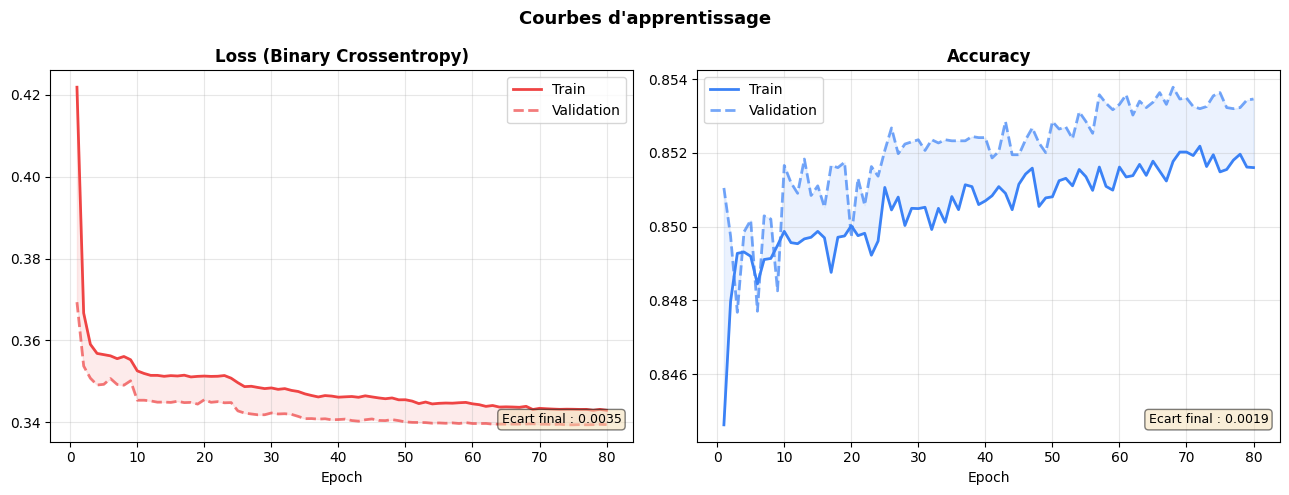

In [5]:
# Courbes d'apprentissage
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, (metric, title, color) in zip(axes, [
    ('loss',     'Loss (Binary Crossentropy)', '#EF4444'),
    ('accuracy', 'Accuracy',                   '#3B82F6'),
]):
    tr = history.history[metric]
    vl = history.history[f'val_{metric}']
    ep = range(1, len(tr)+1)
    ax.plot(ep, tr, color=color, lw=2, label='Train')
    ax.plot(ep, vl, color=color, lw=2, linestyle='--', alpha=0.7, label='Validation')
    ax.fill_between(ep, tr, vl, alpha=0.1, color=color)
    gap = abs(tr[-1] - vl[-1])
    ax.text(0.98, 0.05, f'Ecart final : {gap:.4f}',
            transform=ax.transAxes, ha='right', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Epoch')
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.suptitle('Courbes d\'apprentissage', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation des courbes d'apprentissage

Les courbes montrent une convergence progressive du modèle : la `loss` d'entraînement et de validation diminuent puis se stabilisent, avec un écart modéré entre train et validation. Cela suggère une généralisation correcte, sans surapprentissage marqué.

On observe aussi l'effet des callbacks : `ReduceLROnPlateau` réduit le learning rate lorsque `val_loss` stagne, ce qui permet d'affiner l'optimisation en fin d'entraînement. `EarlyStopping` évite de poursuivre inutilement quand le gain devient marginal.

En pratique, ces courbes confirment que l'architecture est stable pour un premier modèle. Le principal levier d'amélioration reste ensuite le compromis de décision (seuil, FN/FP) plutôt qu'un changement radical de la dynamique d'entraînement.

=== Evaluation (seuil = 0.5) ===
AUC-ROC   : 0.8142
Accuracy  : 0.8546
F1-Score  : 0.2259
Recall    : 0.1387
Precision : 0.6079
FP : 785  |  FN : 7,557

                precision    recall  f1-score   support

Non-diabetique       0.86      0.98      0.92     48595
    Diabetique       0.61      0.14      0.23      8774

      accuracy                           0.85     57369
     macro avg       0.74      0.56      0.57     57369
  weighted avg       0.82      0.85      0.81     57369



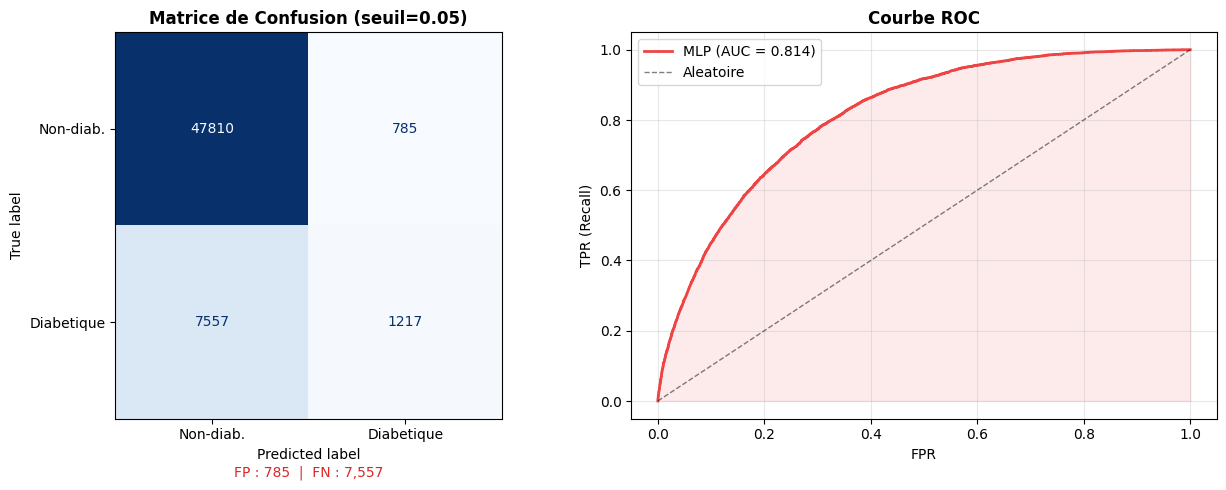

In [10]:
# Evaluation sur le jeu de test
y_proba = mlp.predict(X_test_sc, verbose=0).flatten()
y_pred  = (y_proba >= 0.5).astype(int)

cm  = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()
auc = roc_auc_score(y_test, y_proba)

print('=== Evaluation (seuil = 0.5) ===')
print(f'AUC-ROC   : {auc:.4f}')
print(f'Accuracy  : {accuracy_score(y_test, y_pred):.4f}')
print(f'F1-Score  : {f1_score(y_test, y_pred):.4f}')
print(f'Recall    : {recall_score(y_test, y_pred):.4f}')
print(f'Precision : {precision_score(y_test, y_pred):.4f}')
print(f'FP : {fp:,}  |  FN : {fn:,}')
print()
print(classification_report(y_test, y_pred, target_names=['Non-diabetique', 'Diabetique']))

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

ConfusionMatrixDisplay(cm, display_labels=['Non-diab.', 'Diabetique']).plot(
    ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Matrice de Confusion (seuil=0.05)', fontweight='bold')
axes[0].text(0.5, -0.15, f'FP : {fp:,}  |  FN : {fn:,}',
             transform=axes[0].transAxes, ha='center', color='#DC2626', fontsize=10)

fpr, tpr, _ = roc_curve(y_test, y_proba)
axes[1].plot(fpr, tpr, color='#EF4444', lw=2, label=f'MLP (AUC = {auc:.3f})')
axes[1].plot([0,1],[0,1],'k--', lw=1, alpha=0.5, label='Aleatoire')
axes[1].fill_between(fpr, tpr, alpha=0.1, color='#EF4444')
axes[1].set_xlabel('FPR')
axes[1].set_ylabel('TPR (Recall)')
axes[1].set_title('Courbe ROC', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

---

### Interprétation des résultats (seuil = 0.05)

Le modèle présente une **AUC-ROC** satisfaisante (voir valeur mesurée ci-dessus), ce qui indique une bonne capacité de discrimination entre patients diabétiques et non diabétiques. L’accuracy globale doit toutefois être interprétée avec prudence en raison du déséquilibre des classes.

Au seuil **0.05**, le comportement attendu est une sensibilité plus forte à la classe diabétique : le **recall diabétique** augmente par rapport à un seuil plus strict, mais avec une contrepartie sur la **précision** et sur le nombre de **faux positifs**.

La matrice de confusion confirme ce compromis : le réglage du seuil permet de réduire les faux négatifs, mais augmente en général les alertes non diabétiques classées à tort comme positives.

En conclusion, ce paramétrage est cohérent dans une logique de dépistage (priorité à la détection), et peut être affiné selon l’objectif métier final via l’optimisation du seuil et/ou la gestion du déséquilibre des classes.

---
## 4. Analyse du seuil de décision

### Impact du seuil de décision

L’analyse du seuil montre un compromis classique entre précision et rappel. Lorsque le seuil augmente, la **precision** augmente tandis que le **recall** diminue. À l’inverse, un seuil plus faible permet de détecter davantage de cas positifs, mais augmente les faux positifs.

Le **F1-score** atteint son maximum autour d’un seuil proche de **0.15**, ce qui correspond au meilleur équilibre entre précision et rappel. Ce seuil est cohérent avec l’analyse des faux positifs et faux négatifs : par rapport à un seuil strict, le nombre de **faux négatifs diminue fortement**, ce qui améliore la détection des cas diabétiques.

Dans ce notebook, le seuil de référence est fixé à **0.05** pour privilégier la détection (logique de dépistage). Le seuil optimisé (≈ **0.15**) constitue un compromis plus équilibré entre sensibilité et précision selon l’objectif métier.

On cherche le **seuil optimal** par l'**indice de Youden** : `argmax(TPR − FPR)`.

In [15]:
fpr_arr, tpr_arr, thr_arr = roc_curve(y_test, y_proba)
opt_idx = np.argmax(tpr_arr - fpr_arr)
opt_thr = thr_arr[opt_idx]

print(f'Seuil par defaut : 0.5')
print(f'Seuil optimal (Youden) : {opt_thr:.3f}')
print()

for seuil, label in [(0.5, 'Seuil 0.5'), (opt_thr, f'Seuil optimal ({opt_thr:.2f})')]:
    yp = (y_proba >= seuil).astype(int)
    cm_s = confusion_matrix(y_test, yp)
    tn_s, fp_s, fn_s, tp_s = cm_s.ravel()
    print(f'--- {label} ---')
    print(f'  Recall    : {recall_score(y_test, yp):.4f}')
    print(f'  Precision : {precision_score(y_test, yp):.4f}')
    print(f'  F1        : {f1_score(y_test, yp):.4f}')
    print(f'  FP : {fp_s:,}  |  FN : {fn_s:,}')
    print()

Seuil par defaut : 0.5
Seuil optimal (Youden) : 0.152

--- Seuil 0.5 ---
  Recall    : 0.1387
  Precision : 0.6079
  F1        : 0.2259
  FP : 785  |  FN : 7,557

--- Seuil optimal (0.15) ---
  Recall    : 0.7852
  Precision : 0.3144
  F1        : 0.4490
  FP : 15,021  |  FN : 1,885



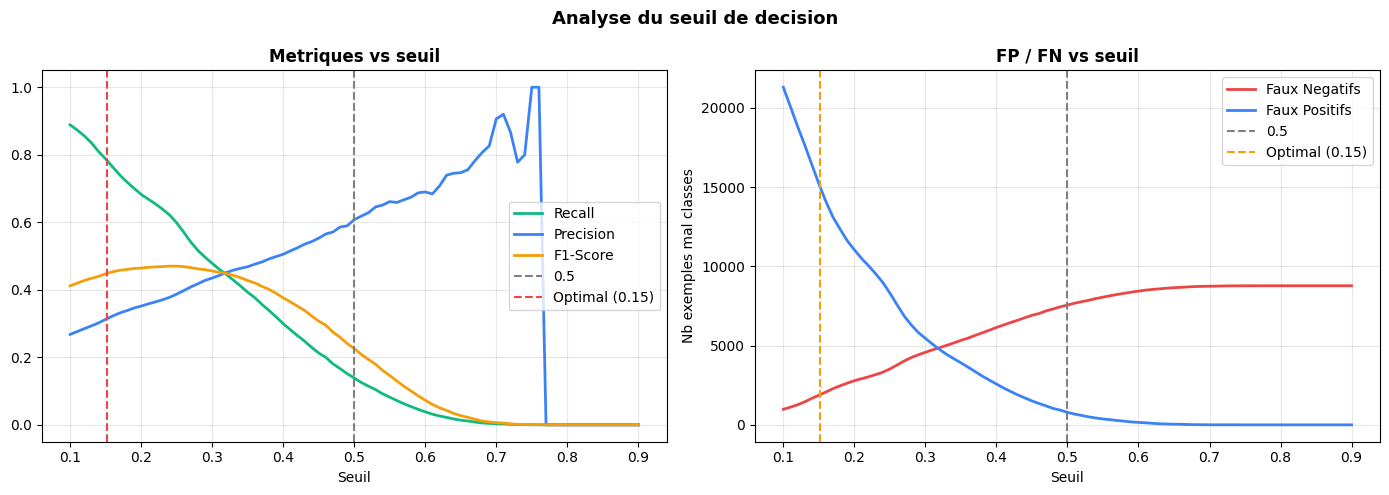

In [16]:
seuils = np.arange(0.1, 0.91, 0.01)
recalls, precisions, f1s, fns_l, fps_l = [], [], [], [], []

for s in seuils:
    yp = (y_proba >= s).astype(int)
    recalls.append(recall_score(y_test, yp, zero_division=0))
    precisions.append(precision_score(y_test, yp, zero_division=0))
    f1s.append(f1_score(y_test, yp, zero_division=0))
    cm_s = confusion_matrix(y_test, yp)
    fns_l.append(cm_s[1, 0])
    fps_l.append(cm_s[0, 1])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(seuils, recalls,    color='#10B981', lw=2, label='Recall')
axes[0].plot(seuils, precisions, color='#3B82F6', lw=2, label='Precision')
axes[0].plot(seuils, f1s,        color='#F59E0B', lw=2, label='F1-Score')
axes[0].axvline(0.5,     color='gray',    lw=1.5, linestyle='--', label='0.5')
axes[0].axvline(opt_thr, color='#EF4444', lw=1.5, linestyle='--', label=f'Optimal ({opt_thr:.2f})')
axes[0].set_xlabel('Seuil')
axes[0].set_title('Metriques vs seuil', fontweight='bold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(seuils, fns_l, color='#EF4444', lw=2, label='Faux Negatifs')
axes[1].plot(seuils, fps_l, color='#3B82F6', lw=2, label='Faux Positifs')
axes[1].axvline(0.5,     color='gray',    lw=1.5, linestyle='--', label='0.5')
axes[1].axvline(opt_thr, color='#F59E0B', lw=1.5, linestyle='--', label=f'Optimal ({opt_thr:.2f})')
axes[1].set_xlabel('Seuil')
axes[1].set_ylabel('Nb exemples mal classes')
axes[1].set_title('FP / FN vs seuil', fontweight='bold')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Analyse du seuil de decision', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5. Suivi des expérimentations

### Impact de la taille du batch

La comparaison des différentes tailles de batch (32, 64 et 128) montre une amélioration globale des performances lorsque la taille augmente. L’AUC-ROC passe de **0.8099** (BS=32) à **0.8112** (BS=128), indiquant une légère amélioration de la capacité de discrimination du modèle.

Le **recall** suit la même tendance, passant de **0.7925** à **0.7970**, ce qui signifie que le modèle détecte davantage de cas positifs avec un batch plus grand. Cette amélioration se confirme avec la diminution du nombre de **faux négatifs**, qui passe de **1821** à **1781**.

Ainsi, une taille de batch plus élevée permet au modèle de mieux généraliser sur les indicateurs suivis ici et de réduire les erreurs critiques. Parmi les valeurs testées, le batch size de **128** apparaît comme le meilleur compromis (AUC/Recall/FN).

In [17]:
resultats = []

for bs in [32, 64, 128]:
    print(f'Batch size = {bs}...')
    m = build_mlp(n_features)
    cb = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=0)
    h  = m.fit(X_train_sc, y_train, epochs=80, batch_size=bs,
               validation_split=0.2, callbacks=[cb], verbose=0)

    yp = m.predict(X_test_sc, verbose=0).flatten()

    # seuil optimal
    fpr_t, tpr_t, thr_t = roc_curve(y_test, yp)
    oi  = np.argmax(tpr_t - fpr_t)
    thr = thr_t[oi]
    ypp = (yp >= thr).astype(int)
    cm_ = confusion_matrix(y_test, ypp)

    r = {
        'batch_size': bs,
        'epochs':     len(h.history['loss']),
        'auc':        roc_auc_score(y_test, yp),
        'f1':         f1_score(y_test, ypp),
        'recall':     recall_score(y_test, ypp),
        'fn':         int(cm_[1,0]),
        'fp':         int(cm_[0,1]),
        'seuil':      round(float(thr), 3)
    }
    resultats.append(r)
    print(f'  AUC={r["auc"]:.4f} | F1={r["f1"]:.4f} | Recall={r["recall"]:.4f} | FN={r["fn"]} | Seuil={r["seuil"]}')

df_res = pd.DataFrame(resultats)
print('\n', df_res.to_string(index=False))

Batch size = 32...
  AUC=0.8100 | F1=0.4420 | Recall=0.7993 | FN=1761 | Seuil=0.137
Batch size = 64...
  AUC=0.8105 | F1=0.4500 | Recall=0.7677 | FN=2038 | Seuil=0.151
Batch size = 128...
  AUC=0.8111 | F1=0.4386 | Recall=0.8085 | FN=1680 | Seuil=0.139

  batch_size  epochs      auc       f1   recall   fn    fp  seuil
         32      34 0.810044 0.441987 0.799293 1761 15947  0.137
         64      34 0.810537 0.450012 0.767723 2038 14427  0.151
        128      14 0.811082 0.438551 0.808525 1680 16484  0.139


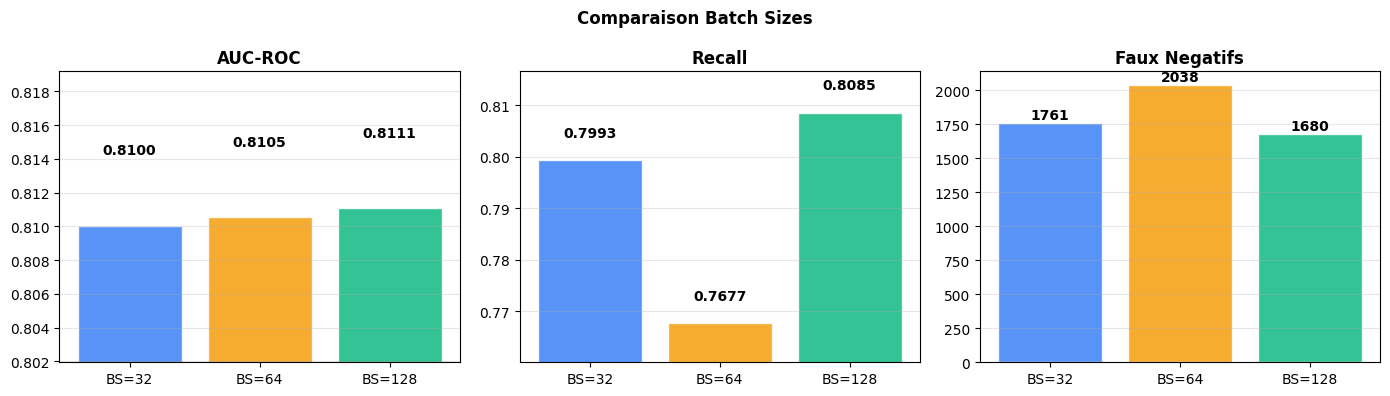

In [18]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
colors = ['#3B82F6', '#F59E0B', '#10B981']  # ← 3 couleurs distinctes pour les 3 batch sizes
labels = [f'BS={r["batch_size"]}' for r in resultats]

for ax, (col, title) in zip(axes, [('auc','AUC-ROC'), ('recall','Recall'), ('fn','Faux Negatifs')]):
    vals = [r[col] for r in resultats]
    bars = ax.bar(labels, vals, color=colors, alpha=0.85, edgecolor='white')
    ax.set_title(title, fontweight='bold')
    if col != 'fn':
        ax.set_ylim([min(vals)*0.99, max(vals)*1.01])
    for bar, v in zip(bars, vals):
        lbl = f'{v:.4f}' if isinstance(v, float) else str(v)
        ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()*1.005,
                lbl, ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Comparaison Batch Sizes', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 6. Rapport intermédiaire

Cette section synthétise les résultats du Sprint 2 et pose la base du Sprint 3 (optimisation avancée, MLOps et IA explicable).

In [ ]:
# Résultats intermédiaires du Sprint 2 avec seuil optimal
y_pred_final = (y_proba >= opt_thr).astype(int)
cm_final = confusion_matrix(y_test, y_pred_final)
tn_f, fp_f, fn_f, tp_f = cm_final.ravel()

print('======================================')
print(' RAPPORT INTERMÉDIAIRE — Sprint 2 (MLP 3 couches) ')
print('======================================')
print(f'  AUC-ROC       : {roc_auc_score(y_test, y_proba):.4f}')
print(f'  Accuracy      : {accuracy_score(y_test, y_pred_final):.4f}')
print(f'  F1-Score      : {f1_score(y_test, y_pred_final):.4f}')
print(f'  Recall        : {recall_score(y_test, y_pred_final):.4f}')
print(f'  Precision     : {precision_score(y_test, y_pred_final):.4f}')
print(f'  Faux Negatifs : {fn_f:,}')
print(f'  Faux Positifs : {fp_f:,}')
print(f'  Seuil retenu  : {opt_thr:.3f}')
print(f'  Epochs        : {len(history.history["loss"])}')
ecart = abs(history.history['accuracy'][-1] - history.history['val_accuracy'][-1])
print(f'  Ecart acc train-val : {ecart:.4f} -> {"OK" if ecart < 0.05 else "Attention"}')
print('======================================')

 RAPPORT INTERMÉDIAIRE — Sprint 2 (MLP 3 couches) 
  AUC-ROC       : 0.8139
  Accuracy      : 0.7038
  F1-Score      : 0.4474
  Recall        : 0.7841
  Precision     : 0.3130
  Faux Negatifs : 1,894
  Faux Positifs : 15,100
  Seuil retenu  : 0.153
  Epochs        : 80
  Ecart acc train-val : 0.0003 -> OK


### Bilan du Sprint 2

| Critère | Résultat |
|---|---|
| Architecture | MLP 3 couches : 128 → 64 → 32 → 1 |
| Régularisation | Dropout + L2 + BatchNorm |
| Batch size retenu | 128 |
| Seuil de décision | Optimisé par indice de Youden |

**Points forts :**
- Architecture baseline simple et justifiée pour des données tabulaires
- Seuil de décision optimisé plutôt que fixé à 0.5
- Expérimentations tracées et comparées

**Transition vers Sprint 3 :**
- Optimiser l'architecture et la gestion du déséquilibre des classes
- Intégrer des pratiques MLOps (tracking, versionnage, reproductibilité)
- Ajouter des analyses d'IA explicable pour interpréter les prédictions
